In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [30]:
# Load Dataset
df=pd.read_csv("spotify-tracks-dataset.csv")
df.head()

,S.no,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [31]:
#Basic Information
print(df.shape)
df.info()

(114000, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   S.no              114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrum

In [32]:
# Removing the Unnecessary Columns
df.drop("Unnamed: 0",axis=1,inplace=True)
df.drop("S.no",axis=1,inplace=True)


In [33]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


**Visual 1:** Average Popularity By Genre

In [34]:
top_genres=df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
top_genres

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64

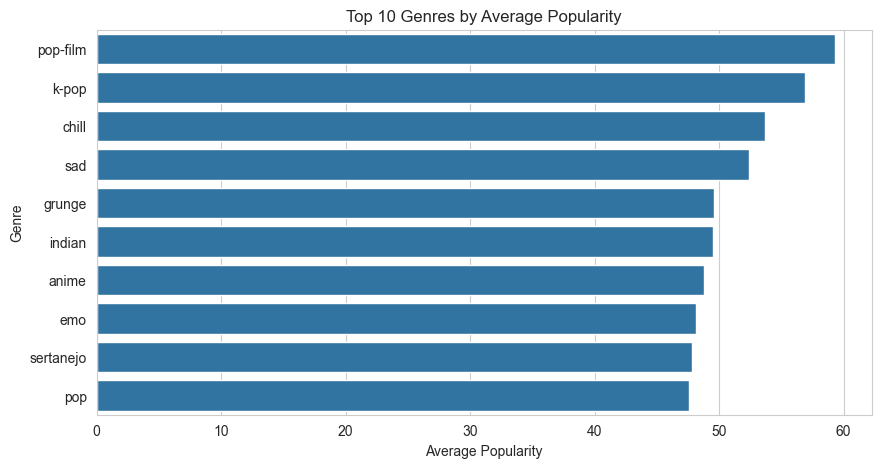

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values,y=top_genres.index)
plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()

In [36]:
df[['track_genre','popularity']].head()

,track_genre,popularity
0,acoustic,73
1,acoustic,55
2,acoustic,57
3,acoustic,71
4,acoustic,82


**Insight:**
- Pop-film is the most popular genre in the dataset.
- K-pop ranks second with an avaerage popularity of about 56.89
- Indian music apperas in the top 10 genres
- Popularity varies significantly across genres.

**Visualization 2:** Top 10 Artists by Average Popularity

In [38]:
df['artists'].head(10)

0                             Gen Hoshino
1                            Ben Woodward
2                  Ingrid Michaelson;ZAYN
3                            Kina Grannis
4                        Chord Overstreet
5                            Tyrone Wells
6    A Great Big World;Christina Aguilera
7                              Jason Mraz
8               Jason Mraz;Colbie Caillat
9                          Ross Copperman
Name: artists, dtype: object

In [41]:
df['artists'].isnull().sum()

np.int64(0)

In [40]:
df.dropna(subset=['artists'],inplace=True)

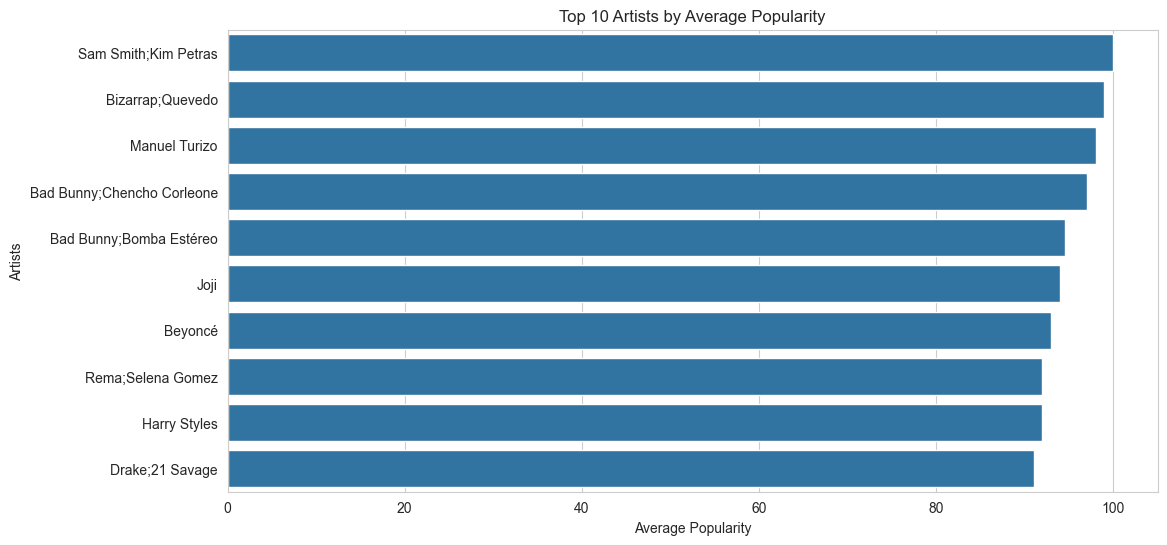

In [42]:
top_artists=df.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_artists.values,y=top_artists.index)
plt.title("Top 10 Artists by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Artists")
plt.show()

**Insight:**
- Sam Smith and Kim Petras have the heighest popularity score in the dataset.
- Followed by Bizarrap and Quevedo and Manuel Turizo

**Visualization 3:** Popularity Distribution

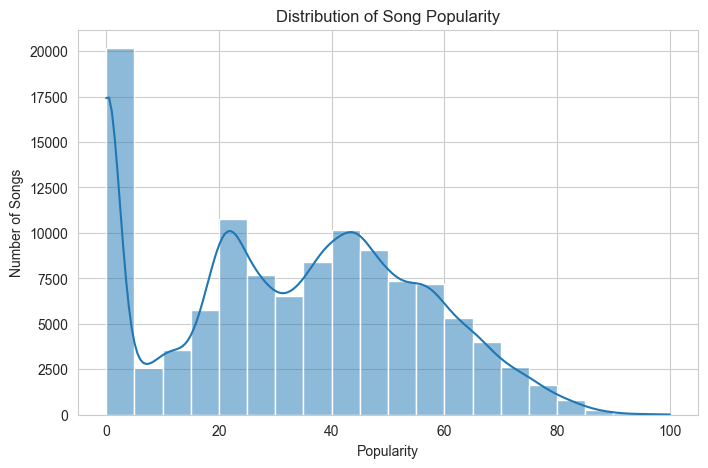

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'],bins=20,kde=True)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

**Insight:**
- This chart shows how song popularity is distributed across the dataset. It helps identify whether most songs are highly popular or have moderate to low popularity.
- Most songs in the dataset have low to moderate popularity, while higly popular songs are relatively rare. 

**Visulization 4:** Explicit Vs Non-Explicit Songs

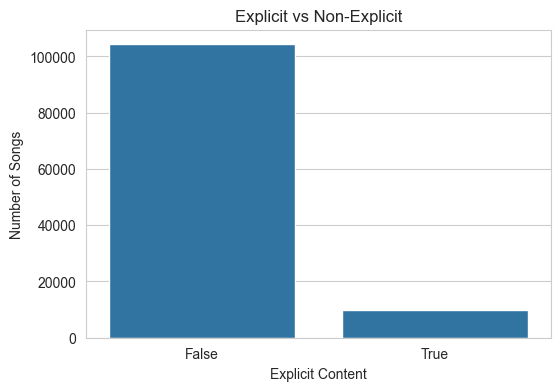

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x='explicit',data=df)

plt.title("Explicit vs Non-Explicit")
plt.xlabel("Explicit Content")
plt.ylabel("Number of Songs")
plt.show()

**Insight:**
- This visualization compafres the number of explicit and non-explicit songs available in the dataset.
- Non-explicit songs are more in the dataset suggesting that a large potion of music tracks are suitable for a general audience. 

**Visualization 5:** Danceability vs Popularity

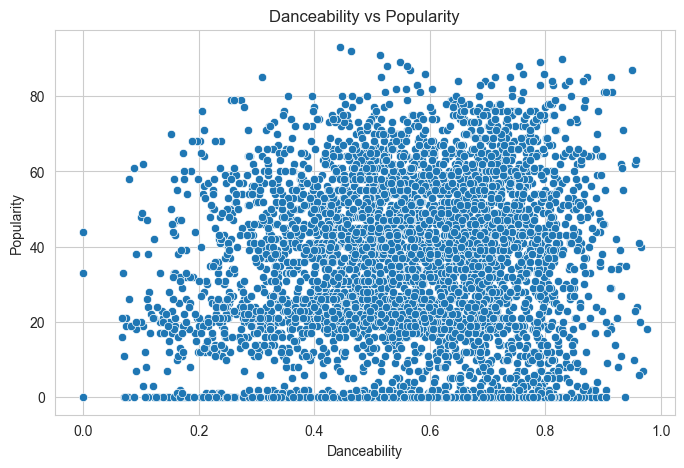

In [48]:
sample_df=df.sample(5000,random_state=42)

plt.figure(figsize=(8,5))
sns.scatterplot(data=sample_df,x='danceability',y='popularity')

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

**Insight:**
- The scatter plot shows a weak positive relationship between danceability and popularity
- While highly danceable songs are often popular, danceability alone does not guarantee higher popularity, as songs with similar danceability scores have a wide range of popularity values.

**Visulization 6:** Energy vs Popularity

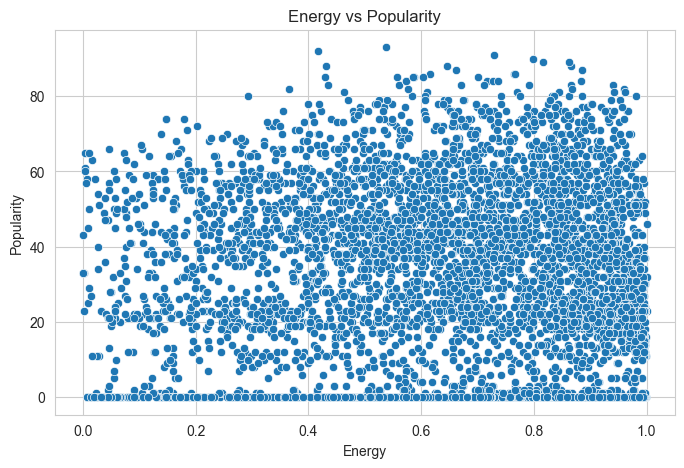

In [56]:
sample_df=df.sample(5000,random_state=42)
plt.figure(figsize=(8,5))
sns.scatterplot(data=sample_df,x='energy',y='popularity')
plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

**Visualization 7:** Duration Distribution


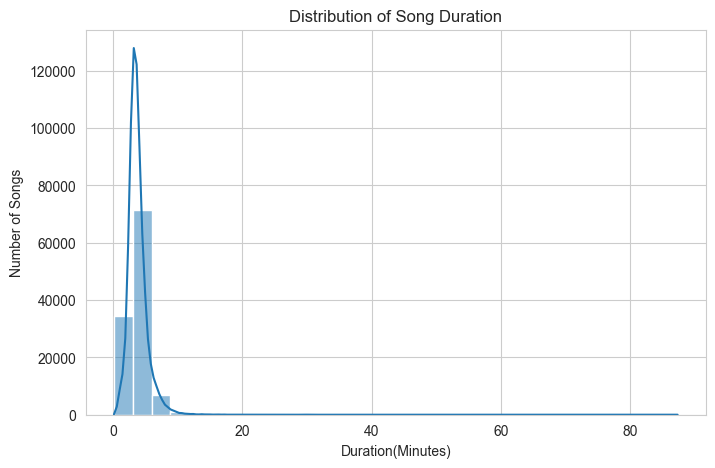

In [50]:
df['duration_min']=df['duration_ms']/60000

plt.figure(figsize=(8,5))
sns.histplot(df['duration_min'],bins=30,kde=True)
plt.title("Distribution of Song Duration")
plt.xlabel("Duration(Minutes)")
plt.ylabel("Number of Songs")
plt.show()

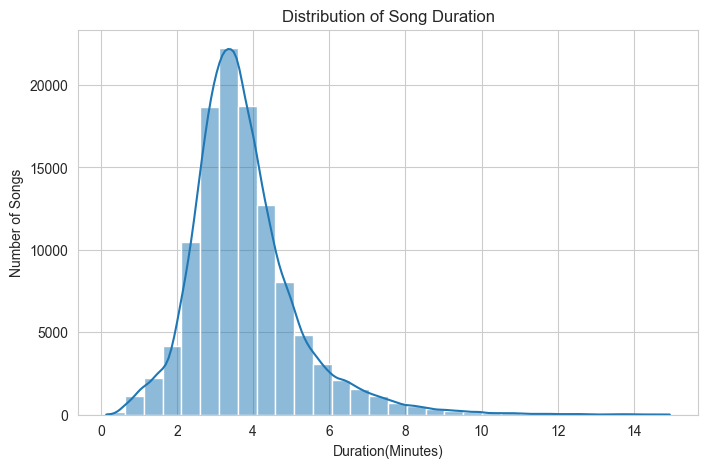

In [52]:
duration_filtered=df[df['duration_min'] <=15]

plt.figure(figsize=(8,5))
sns.histplot(duration_filtered['duration_min'],bins=30,kde=True)
plt.title("Distribution of Song Duration")
plt.xlabel("Duration(Minutes)")
plt.ylabel("Number of Songs")
plt.show()

**Insight:**
- Most songs in the dataset have a duartion between 2 and 5 minutes.
- A small number of tracks are significantly longer, creating a right-skewed distribution and extending the graph up to around 80 minutes. 

**Visualization 8:** Correlation Heatmap

<Axes: >

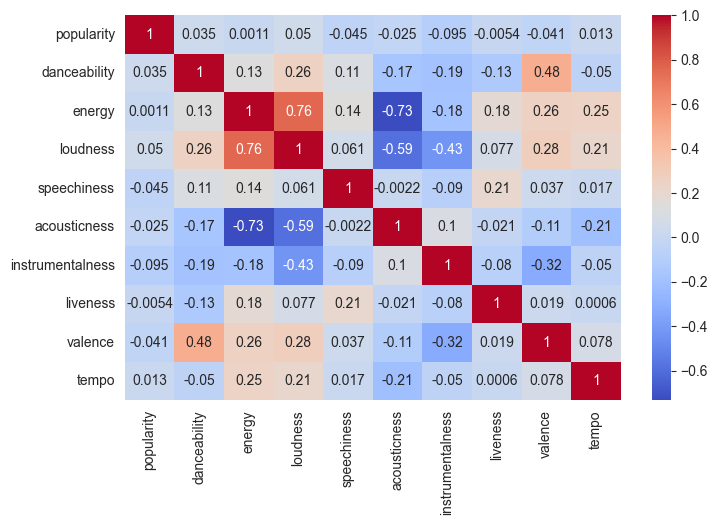

In [53]:
num_cols=['popularity','danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']
plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')

**insights:**
- Songs with higher energy levels tend to be louder. The is the strongest positive realtionship observed in the dataset(0.76).
- Highly energetic songs tend to have lower acoustic characteristics, while acoustic songs generally have lower energy levels(-0.73).
- Happier songs tend to be more danceable (0.48).
- Instrumental tracks generally have lower positivity scores (-0.32).

**Visualization 9:** Top 10 Genres by Average Danceability

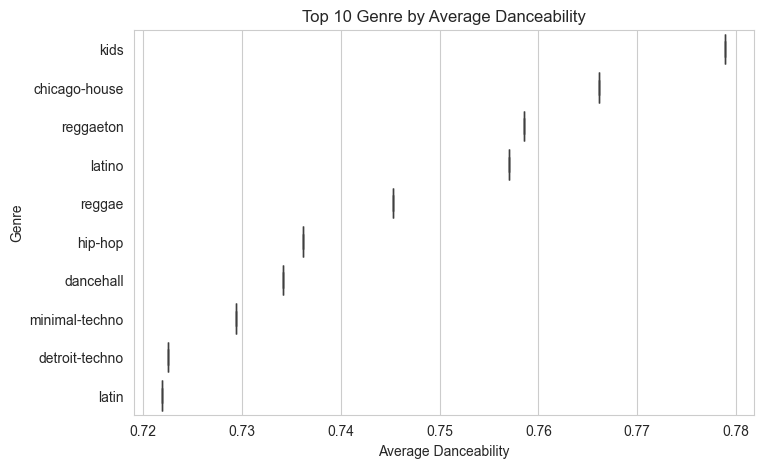

In [54]:
top_dance=df.groupby('track_genre')['danceability'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.boxplot(x=top_dance.values,y=top_dance.index)
plt.title("Top 10 Genre by Average Danceability")
plt.xlabel("Average Danceability")
plt.ylabel("Genre")
plt.show()

**Visualization 10:** Valence Distribution

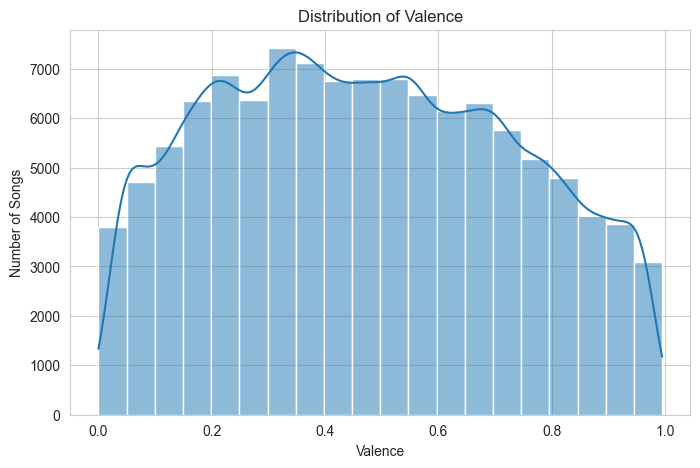

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['valence'],bins=20,kde=True)
plt.title("Distribution of Valence")
plt.xlabel("Valence")
plt.ylabel("Number of Songs")
plt.show()

**Insights:**
- The valence values are spread across the entire range from 0 to 1, with higher concentration between 0.3 and 0.7.
- This suggests that most songs in the dataset have moderate emotional positivity, while extremely sad or extremely happy songs are less common.

**Visulization 11:** Top 10 Genres by Average Energy

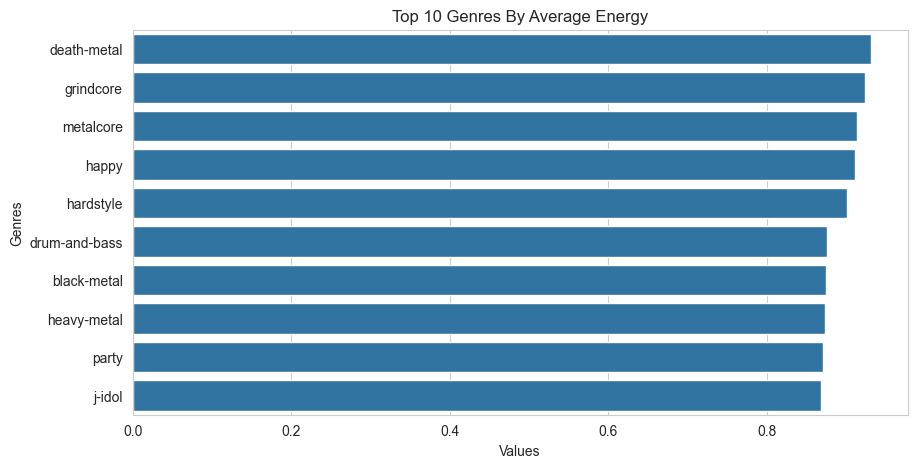

In [57]:
top_energy=df.groupby('track_genre')['energy'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_energy.values,y=top_energy.index)
plt.title("Top 10 Genres By Average Energy")
plt.xlabel("Values")
plt.ylabel("Genres")
plt.show()

**Insights:**
- death-metal genre has the heighest average energy score
- grindcore holds the second position in the list but the differences are really less.
- The list is followed by metalcore, happy, hardstyle,etc genres.


**Visulization 12:** Box Plot of Popularity

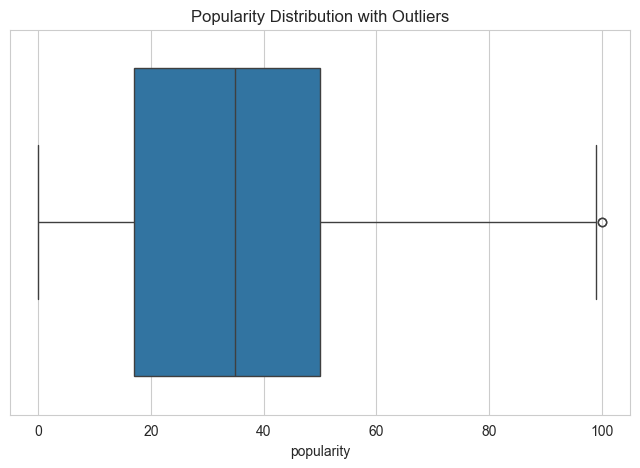

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['popularity'])
plt.title("Popularity Distribution with Outliers")
plt.show()

**Insights:**
Most songs have low to moderate popularity, while only a small proportion achieve very high popularity. This indicates that higly successful tracks are relatively rare.

**Visualization 13:** Violin Plot of Popularity by Explicit Content

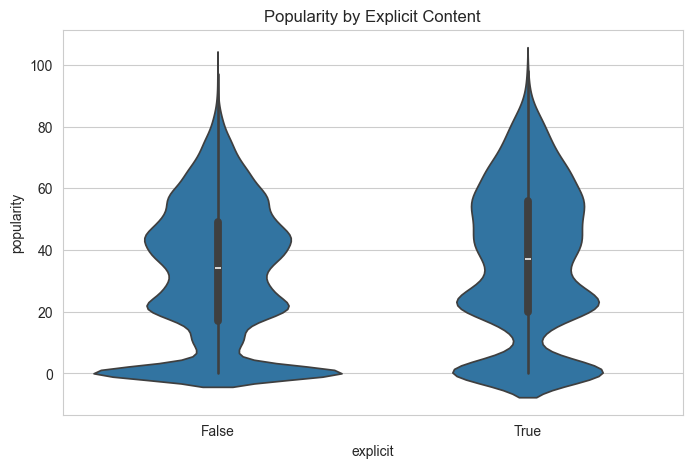

In [59]:
plt.figure(figsize=(8,5))
sns.violinplot(x='explicit',y='popularity',data=df)
plt.title("Popularity by Explicit Content")
plt.show()

**Insights:**
The popularity distribution of explicit and non-explicit songs are very similar. Both categories conatain songs across the entire popularity range, suggesting that explict content alone doe snot have a significant impact on a song's populariyt. Explicit songs shos a slightly higher concentration in the mid to high popularity range, but the diffrence is not substantial.

## Key Findings
1. Pop-film and K-pop are among the most popular genres in the dataset.
2. Most songs have low to moderate popularity, while hihly popular songs are rare.
3. Non-explicit songs outnumber explicit songs.
4. Danceability shows a weak posiitve realionship with popularity.
5. Most songs have a duration between 2 to 5 minutes.
6. Energy and loudness have strong positive correlation (0.76).
7. Energy and acosticness have a strong neagtive correlation (-0.73).
8. Most songs exhibit moderate valence values, indicating balanced emotional tones.

## Business Recommendations
1. Promote highly danceable songs through curated playlist to increase listener engagement.
2. Use audio features such as energy and danceability in recommendatioon system to imporve music discovery.
3. Identify genres with consistently high popularity and priortize them for maketing campaigns.
4. Levrage artist collaborations, as they frequently appear among highly popular tracks.
5. Focus on songs within the most common duration range(2-5 minutes), as they align with listener preferences.

## Conclusion
This project explored and visulaized Spotify track data using Python, pandas, matplotlib nad Seaborn. Various visualizations were created to understand trends in popularity, artist performance, audio characteristics, and listener preferences. The analysis revealed important relationships between audio features such as energy, loudness, danceability, and acousticness. These visual insights demonstrate how data visulaizations can help uncover meaningful patterns in large music datasets.

## Future Scope
1. Build a mcahine leraning model to predict song popularity using audio features.
2. Develop a music recommendation system based on listener preferences.
3. Analyze popularity trends across different genres and artists over time.
4. Create an interactive dashboard using PowerBI or Tableau for real-time exploration.